# Практическая работа №2: Одноканальная СМО (M/M/1)

## Теоретическая справка
Одноканальная система массового обслуживания (СМО) с пуассоновским входящим потоком и экспоненциальным временем обслуживания (модель M/M/1). Ключевые метрики:
- Среднее время ожидания в очереди $W_q$
- Средняя длина очереди $L_q$
- Коэффициент загрузки канала $\rho = \lambda / \mu$

В симуляции мы эмпирически оцениваем эти метрики, собирая статистику по каждому клиенту.

## Старый код

In [ ]:
!pip install simpy

In [4]:
import simpy
import random
import numpy as npя

# Сбор статистики через замыкание
def create_monitor():
    wait_times = []
    queue_lengths = []

    def monitor(env, resource):
        while True:
            yield env.timeout(0.1)  # Снимаем срез каждые 0.1 ед. времени
            queue_lengths.append(len(resource.queue))

    return wait_times, queue_lengths, monitor

# Процесс: клиент приходит в систему
def customer(env, name, counter, wait_times):
    arrival_time = env.now
    print(f'{env.now:6.2f} | {name} пришёл')

    with counter.request() as req:
        yield req
        wait_time = env.now - arrival_time
        wait_times.append(wait_time)
        print(f'{env.now:6.2f} | {name} начал обслуживание (ожидал {wait_time:.2f})')
        yield env.timeout(random.expovariate(1.0))  # Среднее время обслуживания = 1.0
        print(f'{env.now:6.2f} | {name} обслужен')

def customer_generator(env, counter, wait_times):
    i = 0
    while True:
        yield env.timeout(random.expovariate(0.8))  # Интенсивность потока λ = 0.8
        i += 1
        env.process(customer(env, f'Клиент {i}', counter, wait_times))

# Инициализация среды и ресурсов
env = simpy.Environment()
counter = simpy.Resource(env, capacity=1)
wait_times, queue_lengths, monitor = create_monitor()

# Запуск процессов
env.process(customer_generator(env, counter, wait_times))
env.process(monitor(env, counter))

# Симуляция
env.run(until=50)

# Вывод результатов
print(f'\nСтатистика за 50 единиц времени:')


  2.13 | Клиент 1 пришёл
  2.13 | Клиент 1 начал обслуживание (ожидал 0.00)
  2.29 | Клиент 1 обслужен
  2.49 | Клиент 2 пришёл
  2.49 | Клиент 2 начал обслуживание (ожидал 0.00)
  3.56 | Клиент 2 обслужен
  4.06 | Клиент 3 пришёл
  4.06 | Клиент 3 начал обслуживание (ожидал 0.00)
  4.37 | Клиент 4 пришёл
  4.72 | Клиент 3 обслужен
  4.72 | Клиент 4 начал обслуживание (ожидал 0.35)
  6.73 | Клиент 4 обслужен
  7.61 | Клиент 5 пришёл
  7.61 | Клиент 5 начал обслуживание (ожидал 0.00)
  8.26 | Клиент 5 обслужен
  8.99 | Клиент 6 пришёл
  8.99 | Клиент 6 начал обслуживание (ожидал 0.00)
 10.61 | Клиент 6 обслужен
 10.87 | Клиент 7 пришёл
 10.87 | Клиент 7 начал обслуживание (ожидал 0.00)
 11.29 | Клиент 8 пришёл
 11.79 | Клиент 7 обслужен
 11.79 | Клиент 8 начал обслуживание (ожидал 0.51)
 12.08 | Клиент 8 обслужен
 17.23 | Клиент 9 пришёл
 17.23 | Клиент 9 начал обслуживание (ожидал 0.00)
 18.53 | Клиент 9 обслужен
 19.03 | Клиент 10 пришёл
 19.03 | Клиент 10 начал обслуживание (ожидал 0

## Новый код

### Интенсивность потока 1.2

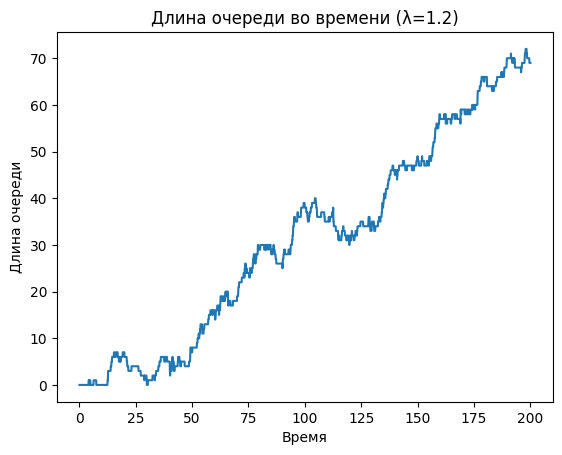


Статистика за 200 единиц времени:
Среднее время ожидания: 23.216
Среднее время в системе: 24.109
Средняя длина очереди: 31.251


In [20]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# Сбор статистики через замыкание
def create_monitor():
    wait_times = []
    system_times = []   # время в системе (новое)
    queue_lengths = []
    times = []

    def monitor(env, resource):
        while True:
            yield env.timeout(0.1)
            queue_lengths.append(len(resource.queue))
            times.append(env.now)

    return wait_times, system_times, queue_lengths, times, monitor

# Процесс: клиент приходит в систему
def customer(env, name, counter, wait_times, system_times):
    arrival_time = env.now
    # print(f'{env.now:6.2f} | {name} пришёл')

    with counter.request() as req:
        yield req

        start_service = env.now
        wait_time = start_service - arrival_time
        wait_times.append(wait_time)

        # print(f'{env.now:6.2f} | {name} начал обслуживание (ожидал {wait_time:.2f})')
        yield env.timeout(random.expovariate(1.0))   # Среднее время обслуживания = 1.0
        # print(f'{env.now:6.2f} | {name} обслужен')

        total_time = env.now - arrival_time
        system_times.append(total_time)

def customer_generator(env, counter, wait_times, system_times):
    i = 0
    while True:
        yield env.timeout(random.expovariate(1.2))  # Интенсивность потока λ = 1.2 - поменяли
        i += 1
        env.process(customer(env, f'Клиент {i}', counter, wait_times, system_times))

def run_simulation(mu, capacity, sim_time=200): #время симуляции поменяли
    # Инициализация среды и ресурсов
    env = simpy.Environment()
    counter = simpy.Resource(env, capacity)

    wait_times, system_times, queue_lengths, times, monitor = create_monitor()

    # Запуск процессов
    env.process(customer_generator(env, counter, wait_times, system_times))
    env.process(monitor(env, counter))

    # Симуляция
    env.run(until=sim_time)

    return {
        "wait_times": wait_times,
        "system_times": system_times,
        "queue_lengths": queue_lengths,
        "times": times
    }


mu = 1.0
capacity = 1
result = run_simulation(mu, capacity)

# График 1: длина очереди во времени
plt.figure()
plt.plot(result["times"], result["queue_lengths"])
plt.xlabel("Время")
plt.ylabel("Длина очереди")
plt.title("Длина очереди во времени (λ=1.2)")
plt.show()


# Вывод статистики
print("\nСтатистика за 200 единиц времени:")
print(f"Среднее время ожидания: {np.mean(result['wait_times']):.3f}")
print(f"Среднее время в системе: {np.mean(result['system_times']):.3f}")
print(f"Средняя длина очереди: {np.mean(result['queue_lengths']):.3f}")

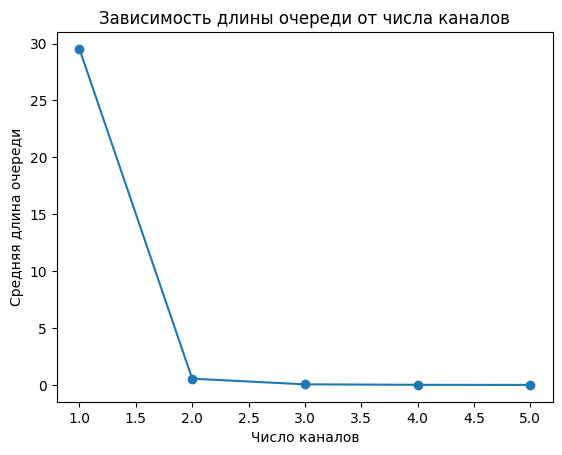

In [21]:
# 2. Зависимость от числа каналов
channels = [1, 2, 3, 4, 5]
avg_queue_lengths = []

for c in channels:
    res = run_simulation(mu, capacity=c)
    avg_queue_lengths.append(np.mean(res["queue_lengths"]))

plt.figure()
plt.plot(channels, avg_queue_lengths, marker='o')
plt.xlabel("Число каналов")
plt.ylabel("Средняя длина очереди")
plt.title("Зависимость длины очереди от числа каналов")
plt.show()

#### Сравнение теории и эмпирических результатов (λ = 1.2)

In [26]:
# Сравнение теории и практики
lam = 1.2  # интенсивность входного потока
rho = lam / mu

print("\n=== СРАВНЕНИЕ С ТЕОРИЕЙ M/M/1 ===")
print(f"λ = {lam}, μ = {mu}, ρ = {rho:.3f}")

# Эмпирические значения
Lq_exp = np.mean(result['queue_lengths'])
Wq_exp = np.mean(result['wait_times'])
W_exp = np.mean(result['system_times'])

print("\n--- Эмпирические значения ---")
print(f"Lq (средняя длина очереди): {Lq_exp:.3f}")
print(f"Wq (среднее время ожидания): {Wq_exp:.3f}")
print(f"W  (среднее время в системе): {W_exp:.3f}")

# Теоретические значения

if rho < 1:
    ("\n--- Теоретические значения ---")
    Lq_theory = rho**2 / (1 - rho)
    Wq_theory = rho / (mu - lam)
    W_theory = 1 / (mu - lam)

    print(f"Lq теория: {Lq_theory:.3f}")
    print(f"Wq теория: {Wq_theory:.3f}")
    print(f"W  теория: {W_theory:.3f}")

    print("\n--- СРАВНЕНИЕ ---")
    print(f"Разница Lq: {abs(Lq_exp - Lq_theory):.3f}")
    print(f"Разница Wq: {abs(Wq_exp - Wq_theory):.3f}")
    print(f"Разница W : {abs(W_exp - W_theory):.3f}")

    print("\nВЫВОД:")
    print("Система устойчива (ρ < 1).")

else:
    print("ρ > 1 → система перегружена")


=== СРАВНЕНИЕ С ТЕОРИЕЙ M/M/1 ===
λ = 1.2, μ = 1.0, ρ = 1.200

--- Эмпирические значения ---
Lq (средняя длина очереди): 31.251
Wq (среднее время ожидания): 23.216
W  (среднее время в системе): 24.109
ρ > 1 → система перегружена


### Интенсивность потока 0.8

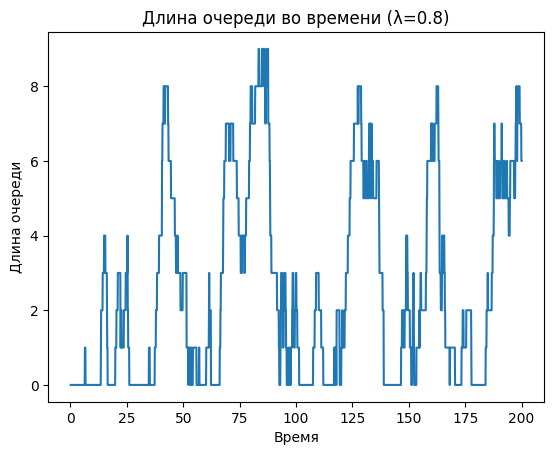


Статистика за 200 единиц времени:
Среднее время ожидания: 2.947
Среднее время в системе: 3.912
Средняя длина очереди: 2.572


In [30]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# Сбор статистики через замыкание
def create_monitor():
    wait_times = []
    system_times = []   # время в системе (новое)
    queue_lengths = []
    times = []

    def monitor(env, resource):
        while True:
            yield env.timeout(0.1)
            queue_lengths.append(len(resource.queue))
            times.append(env.now)

    return wait_times, system_times, queue_lengths, times, monitor

# Процесс: клиент приходит в систему
def customer(env, name, counter, wait_times, system_times):
    arrival_time = env.now
    # print(f'{env.now:6.2f} | {name} пришёл')

    with counter.request() as req:
        yield req

        start_service = env.now
        wait_time = start_service - arrival_time
        wait_times.append(wait_time)

        # print(f'{env.now:6.2f} | {name} начал обслуживание (ожидал {wait_time:.2f})')
        yield env.timeout(random.expovariate(1.0))   # Среднее время обслуживания = 1.0
        # print(f'{env.now:6.2f} | {name} обслужен')

        total_time = env.now - arrival_time
        system_times.append(total_time)

def customer_generator(env, counter, wait_times, system_times):
    i = 0
    while True:
        yield env.timeout(random.expovariate(0.8))  # Интенсивность потока λ = 0.8 - поменяли
        i += 1
        env.process(customer(env, f'Клиент {i}', counter, wait_times, system_times))

def run_simulation(mu, capacity, sim_time=200): #время симуляции поменяли
    # Инициализация среды и ресурсов
    env = simpy.Environment()
    counter = simpy.Resource(env, capacity)

    wait_times, system_times, queue_lengths, times, monitor = create_monitor()

    # Запуск процессов
    env.process(customer_generator(env, counter, wait_times, system_times))
    env.process(monitor(env, counter))

    # Симуляция
    env.run(until=sim_time)

    return {
        "wait_times": wait_times,
        "system_times": system_times,
        "queue_lengths": queue_lengths,
        "times": times
    }


mu = 1.0
capacity = 1
result = run_simulation(mu, capacity)

# График 1: длина очереди во времени
plt.figure()
plt.plot(result["times"], result["queue_lengths"])
plt.xlabel("Время")
plt.ylabel("Длина очереди")
plt.title("Длина очереди во времени (λ=0.8)")
plt.show()


# Вывод статистики
print("\nСтатистика за 200 единиц времени:")
print(f"Среднее время ожидания: {np.mean(result['wait_times']):.3f}")
print(f"Среднее время в системе: {np.mean(result['system_times']):.3f}")
print(f"Средняя длина очереди: {np.mean(result['queue_lengths']):.3f}")

#### Сравнение теории и эмпирических результатов (λ = 0.8)

In [31]:
# Сравнение теории и практики
lam = 0.8  # интенсивность входного потока
rho = lam / mu

print("\n=== СРАВНЕНИЕ С ТЕОРИЕЙ M/M/1 ===")
print(f"λ = {lam}, μ = {mu}, ρ = {rho:.3f}")

# Эмпирические значения
Lq_exp = np.mean(result['queue_lengths'])
Wq_exp = np.mean(result['wait_times'])
W_exp = np.mean(result['system_times'])

print("\n--- Эмпирические значения ---")
print(f"Lq (средняя длина очереди): {Lq_exp:.3f}")
print(f"Wq (среднее время ожидания): {Wq_exp:.3f}")
print(f"W  (среднее время в системе): {W_exp:.3f}")

# Теоретические значения

if rho < 1:
    ("\n--- Теоретические значения ---")
    Lq_theory = rho**2 / (1 - rho)
    Wq_theory = rho / (mu - lam)
    W_theory = 1 / (mu - lam)

    print(f"Lq теория: {Lq_theory:.3f}")
    print(f"Wq теория: {Wq_theory:.3f}")
    print(f"W  теория: {W_theory:.3f}")

    print("\n--- СРАВНЕНИЕ ---")
    print(f"Разница Lq: {abs(Lq_exp - Lq_theory):.3f}")
    print(f"Разница Wq: {abs(Wq_exp - Wq_theory):.3f}")
    print(f"Разница W : {abs(W_exp - W_theory):.3f}")

    print("\nВЫВОД:")
    print("Система устойчива (ρ < 1).")

else:
    print("ρ > 1 → система перегружена")


=== СРАВНЕНИЕ С ТЕОРИЕЙ M/M/1 ===
λ = 0.8, μ = 1.0, ρ = 0.800

--- Эмпирические значения ---
Lq (средняя длина очереди): 2.572
Wq (среднее время ожидания): 2.947
W  (среднее время в системе): 3.912
Lq теория: 3.200
Wq теория: 4.000
W  теория: 5.000

--- СРАВНЕНИЕ ---
Разница Lq: 0.628
Разница Wq: 1.053
Разница W : 1.088

ВЫВОД:
Система устойчива (ρ < 1).


## Задание для самостоятельной работы
1. Измените интенсивность потока на λ = 1.2 (перегрузка системы)
2. Увеличьте время симуляции до 200 единиц для получения устойчивой статистики
3. Добавьте сбор статистики по времени пребывания в системе (ожидание + обслуживание)
4. Постройте графики: длины очереди во времени; длины очереди от количества каналов обслуживания с помощью matplotlib
5. Сравните эмпирические результаты с теоретическими формулами для M/M/1 при ρ < 1 и ρ > 1

## Контрольные вопросы
1. Что означает условие ρ < 1 для устойчивости СМО?
2. Почему при ρ > 1 очередь будет расти неограниченно?
3. Как в SimPy моделируется случайное время между событиями с экспоненциальным распределением?
4. Для чего нужен мониторинг состояния очереди с фиксированным шагом?
5. Какие ограничения имеет модель M/M/1 по сравнению с реальными системами?

## Ответы на вопросы
**1. Что означает условие ρ < 1 для устойчивости СМО?**

Система обслуживает быстрее, чем приходят заявки

`𝜌 = (𝜆 / 𝜇) < 1`
*   λ — как часто приходят клиенты
*   μ — как быстро их обслуживают
Если ρ < 1 → очередь не накапливается, система работает стабильно


**2. Почему при ρ > 1 очередь будет расти неограниченно?**

Потому что:
*   Клиенты приходят быстрее, чем их успевают обслуживать
*   Каждый новый клиент добавляется в очередь

В итоге:
*   Очередь растёт
*   Система не успевает разгрузиться
*   Длина очереди уходит в бесконечность


**3. Как в SimPy моделируется случайное время между событиями с экспоненциальным распределением?**

Через функцию: `random.expovariate(λ)`

И используется так: `yield env.timeout(random.expovariate(λ))`

Это означает:
*   Подождать случайное время
*   С экспоненциальным распределением (как в теории M/M/1)

**4. Для чего нужен мониторинг состояния очереди с фиксированным шагом?**

Чтобы:
*   Отслеживать, как меняется очередь во времени
*   Строить графики
*   Считать средние значения

Если не делать мониторинг, мы не узнаем поведение системы во времени

**5. Какие ограничения имеет модель M/M/1 по сравнению с реальными системами?**

Модель сильно упрощает реальность:
*   один канал обслуживания (в жизни их часто несколько)
*   экспоненциальные распределения (не всегда так)
*   все клиенты одинаковые
*   нет приоритетов
*   бесконечная очередь
*   нет отказов и ограничений

В реальности системы сложнее, поэтому M/M/1 — это приближение, а не точная модель